### 1. What is unsupervised learning in machine learning?

**Answer:** Unsupervised learning is a type of machine learning where the model learns patterns from unlabeled data without predefined outputs.

### 2. How does K-Means clustering algorithm work?

**Answer:** K-Means partitions data into K clusters by assigning points to nearest centroid and updating centroids iteratively.

### 3. Explain dendrogram in hierarchical clustering.

**Answer:** A dendrogram is a tree diagram showing hierarchical relationships between clusters.

### 4. Difference between K-Means and Hierarchical Clustering?

**Answer:** K-Means is partition-based and needs K, hierarchical builds tree and doesn’t require K initially.

### 5. Advantages of DBSCAN over K-Means?

**Answer:** Detects arbitrary shapes and identifies noise without needing number of clusters.

### 6. When to use Silhouette Score?

**Answer:** Used to evaluate clustering quality when true labels are not available.

### 7. Limitations of Hierarchical Clustering?

**Answer:** High computational cost and not scalable for large datasets.

### 8. Why feature scaling is important?

**Answer:** Ensures equal contribution of features in distance-based algorithms.

### 9. How DBSCAN identifies noise?

**Answer:** Points not belonging to any dense region are labeled as noise.

### 10. Define inertia in K-Means.

**Answer:** Sum of squared distances between points and their cluster centroid.

### 11. What is elbow method?

**Answer:** Used to find optimal K by plotting inertia vs K.

### 12. Density in DBSCAN?

**Answer:** Number of points in a neighborhood within eps radius.

### 13. Can hierarchical clustering use categorical data?

**Answer:** Yes, using appropriate distance metrics.

### 14. What does negative silhouette score indicate?

**Answer:** Poor clustering; data point assigned to wrong cluster.

### 15. Linkage criteria?

**Answer:** Defines how distance between clusters is calculated.

### 16. Why K-Means fails on varying densities?

**Answer:** Assumes equal cluster size and shape.

### 17. Core parameters in DBSCAN?

**Answer:** eps and min_samples define density threshold.

### 18. K-Means++ improvement?

**Answer:** Better centroid initialization to avoid poor convergence.

### 19. What is agglomerative clustering?

**Answer:** Bottom-up hierarchical clustering approach.

### 20. Why silhouette better than inertia?

**Answer:** Considers both cohesion and separation of clusters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris, load_wine, load_breast_cancer, load_digits
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

### 21. Generate blobs and apply KMeans

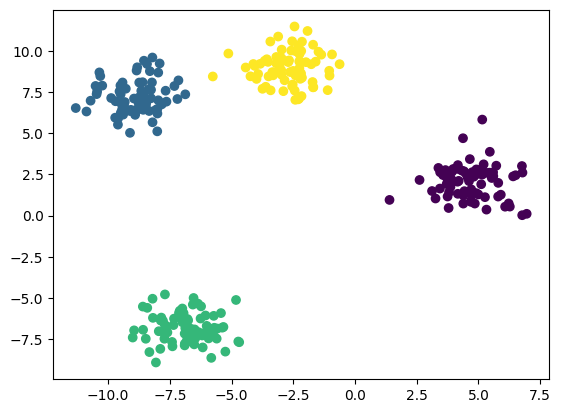

In [2]:
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)
kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 22. Iris with Agglomerative

In [3]:
data = load_iris().data
model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(data)
print(labels[:10])

[1 1 1 1 1 1 1 1 1 1]


### 23. Moons with DBSCAN

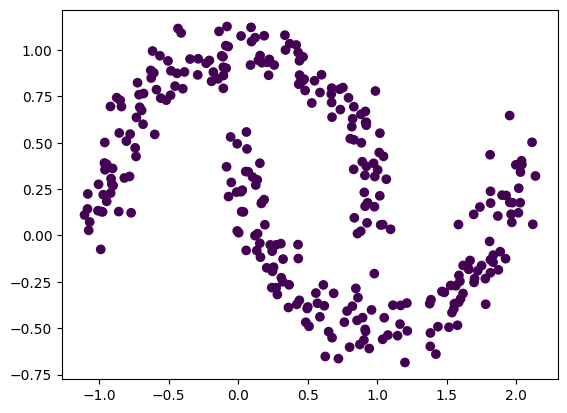

In [4]:
X, _ = make_moons(n_samples=300, noise=0.1)
db = DBSCAN(eps=0.3)
labels = db.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 24. Wine with KMeans

In [5]:
data = StandardScaler().fit_transform(load_wine().data)
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(data)
print(np.bincount(labels))

[66 51 61]


### 25. Circles with DBSCAN

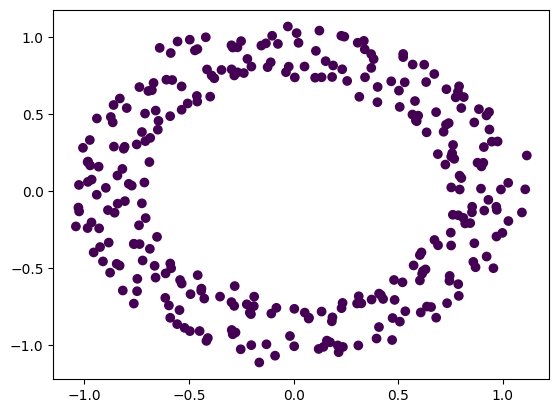

In [6]:
X, _ = make_circles(n_samples=300, noise=0.05)
labels = DBSCAN(eps=0.2).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 26. Breast cancer KMeans

In [7]:
data = MinMaxScaler().fit_transform(load_breast_cancer().data)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)
print(kmeans.cluster_centers_)

[[0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]
 [0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]]


### 27. PCA + Digits

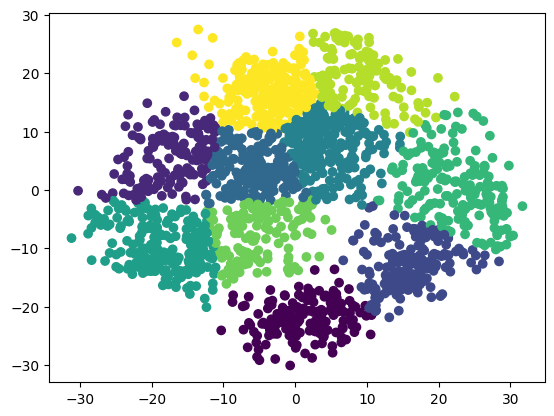

In [8]:
digits = load_digits().data
X = PCA(n_components=2).fit_transform(digits)
labels = KMeans(n_clusters=10).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 28. Silhouette score

In [9]:
X, _ = make_blobs(n_samples=300)
for k in range(2,6):
    labels = KMeans(n_clusters=k).fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.6689460260022345
3 0.7650558357568671
4 0.6042087870393148
5 0.4576672656648998


### 29. DBSCAN noise count

In [10]:
data = load_iris().data
labels = DBSCAN(eps=0.5).fit_predict(data)
print(sum(labels==-1))

17


### 30. 3D PCA Digits

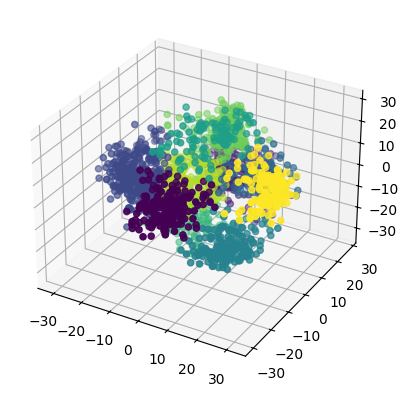

In [11]:
digits = load_digits().data
X = PCA(n_components=3).fit_transform(digits)
labels = KMeans(n_clusters=10).fit_predict(X)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=labels)
plt.show()

### 31. Additional clustering task

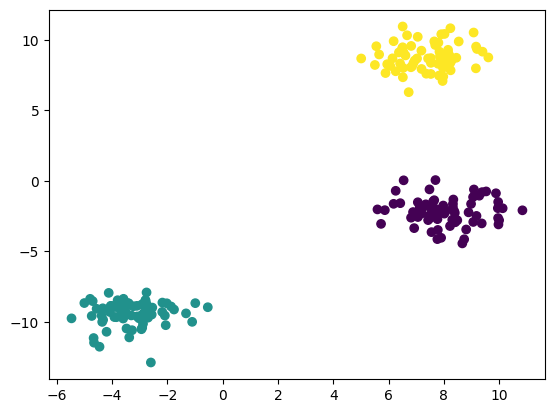

In [12]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 32. Additional clustering task

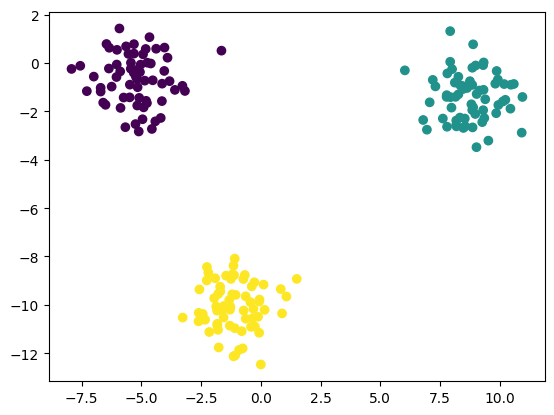

In [13]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 33. Additional clustering task

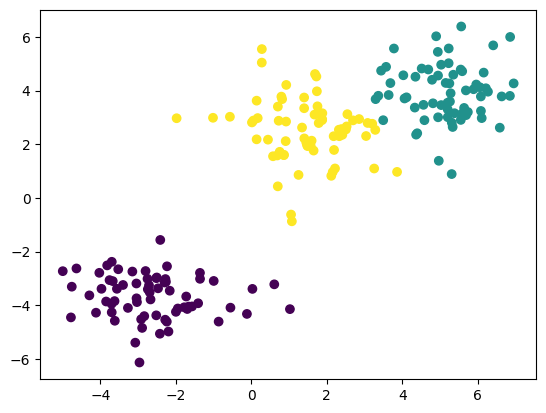

In [14]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 34. Additional clustering task

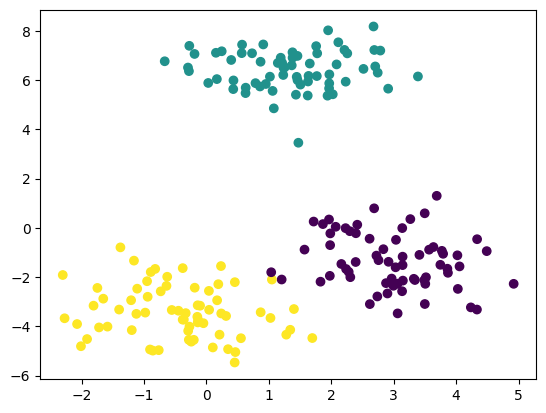

In [15]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 35. Additional clustering task

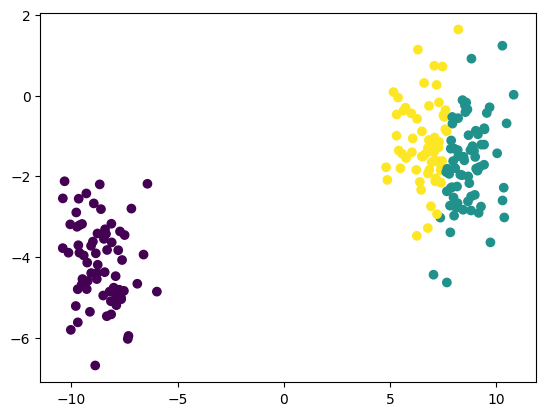

In [16]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 36. Additional clustering task

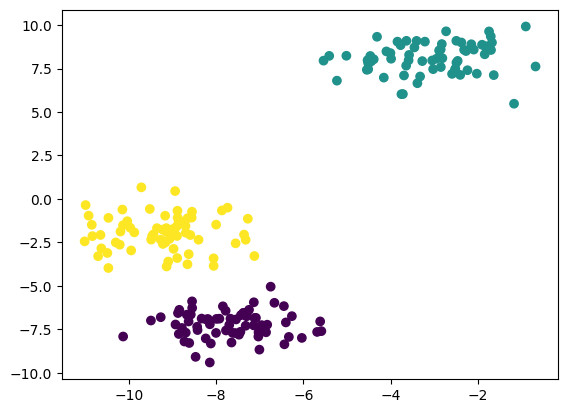

In [17]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 37. Additional clustering task

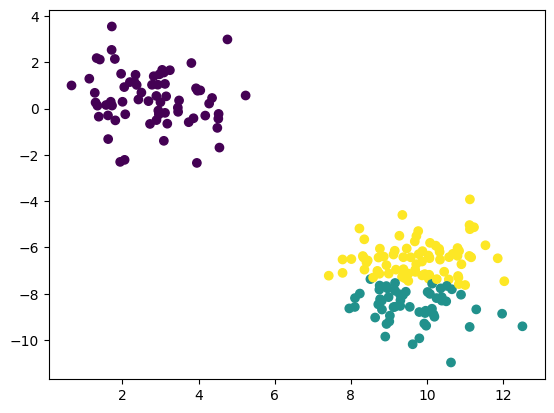

In [18]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 38. Additional clustering task

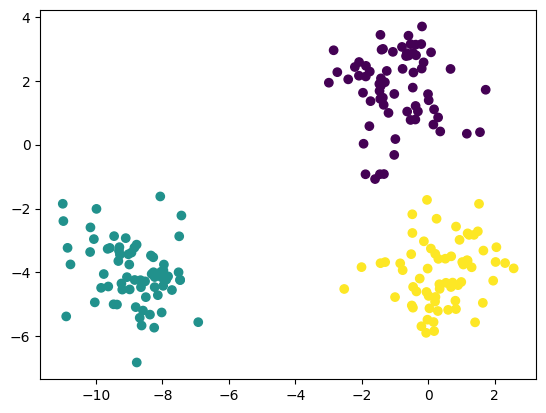

In [19]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 39. Additional clustering task

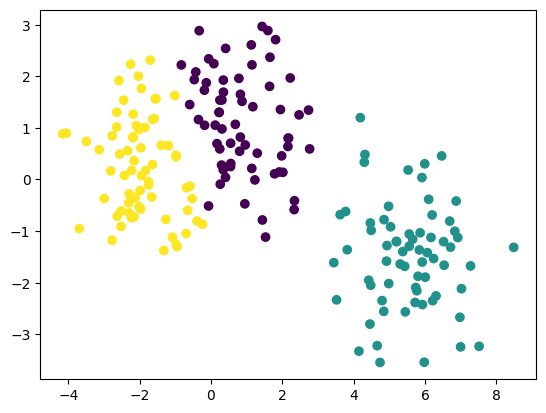

In [20]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 40. Additional clustering task

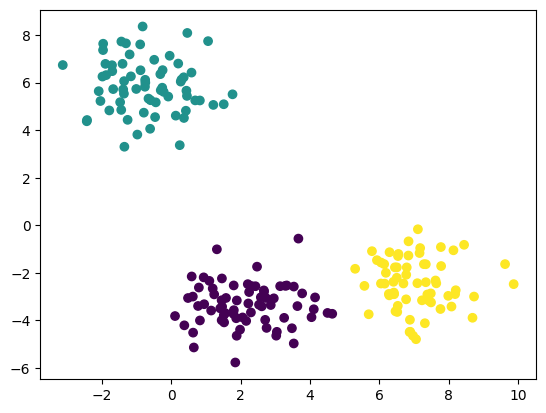

In [21]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 41. Additional clustering task

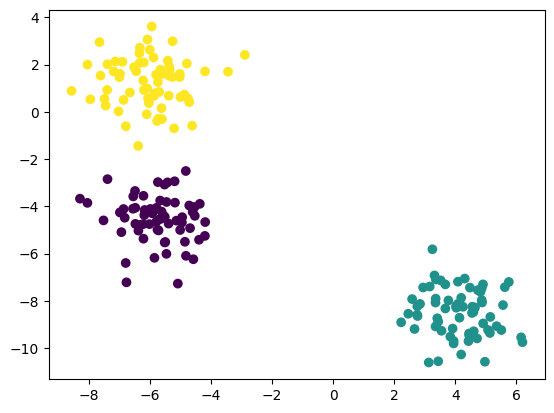

In [22]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 42. Additional clustering task

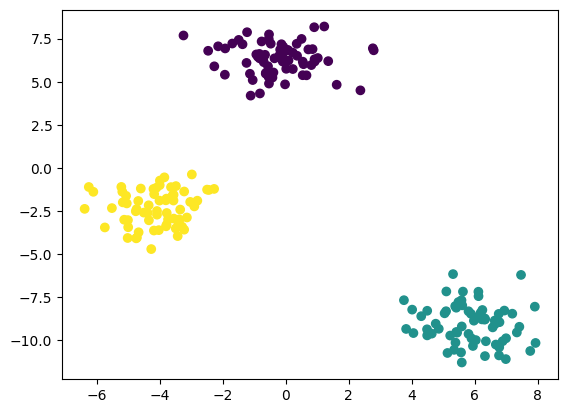

In [23]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 43. Additional clustering task

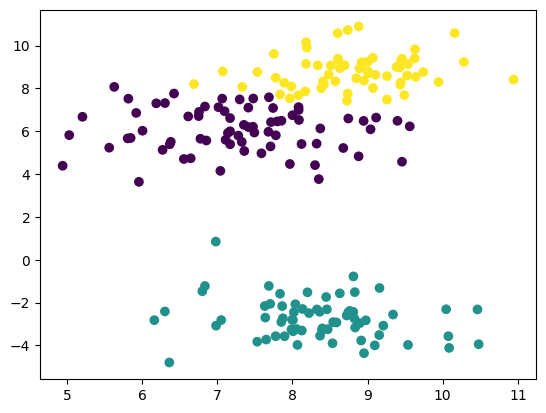

In [24]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 44. Additional clustering task

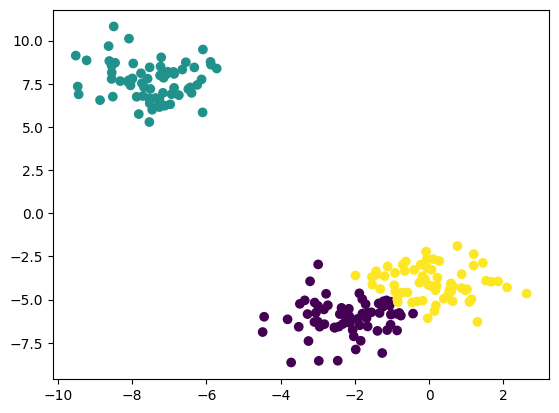

In [25]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 45. Additional clustering task

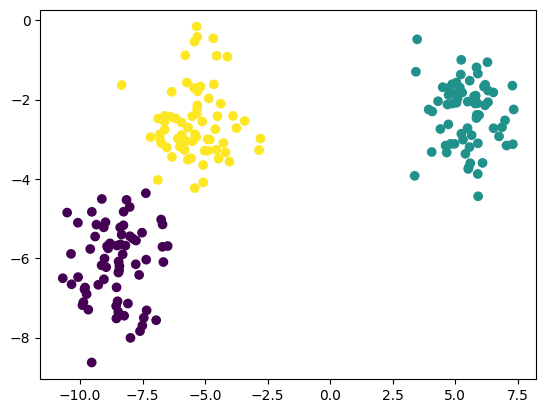

In [26]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 46. Additional clustering task

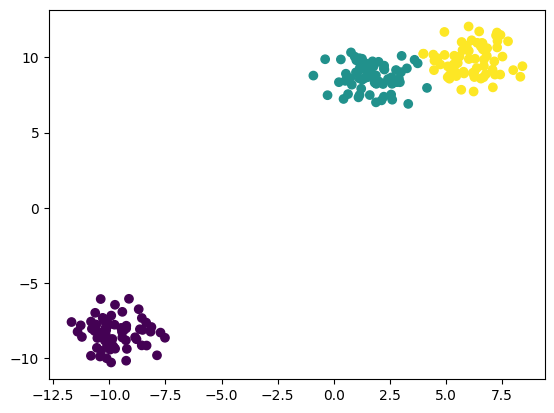

In [27]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 47. Additional clustering task

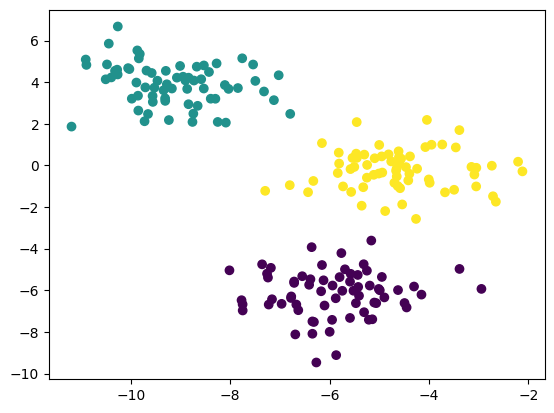

In [28]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

### 48. Additional clustering task

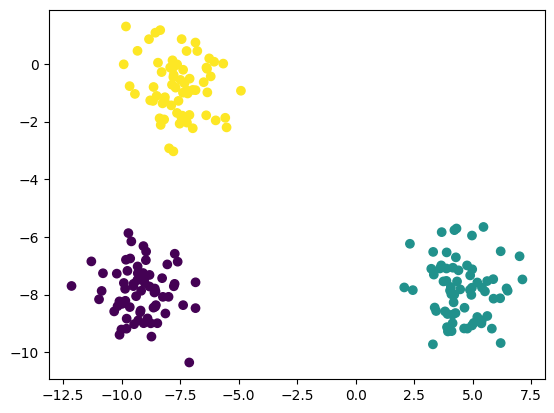

In [29]:
X, _ = make_blobs(n_samples=200)
labels = KMeans(n_clusters=3).fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()